Roll No.: 10

Name: Shubham Khairnar

Date of Performance: 25 Mar 2026

Problem Statement:  Develop an actor-critic model using neural networks and train it on a classic RL benchmark, such as
the Acrobot or Inverted Pendulum.

In [ ]:
!pip install gymnasium torch numpy matplotlib

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Shared layers
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )

        # Actor (policy)
        self.actor = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

        # Critic (value)
        self.critic = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state):
        x = self.shared(state)
        policy = self.actor(x)
        value = self.critic(x)
        return policy, value

In [ ]:
env = gym.make("Acrobot-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

model = ActorCritic(state_dim, action_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

gamma = 0.99
episodes = 500

scores = []

for ep in range(episodes):
    state, _ = env.reset()
    state = torch.FloatTensor(state)

    log_probs = []
    values = []
    rewards = []

    total_reward = 0

    while True:
        policy, value = model(state)

        dist = torch.distributions.Categorical(policy)
        action = dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        log_probs.append(dist.log_prob(action))
        values.append(value)
        rewards.append(reward)

        state = torch.FloatTensor(next_state)
        total_reward += reward

        if done:
            break

    # ----- Compute Returns -----
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.FloatTensor(returns)
    values = torch.cat(values).squeeze()

    # ----- Advantage -----
    advantages = returns - values.detach()

    # ----- Loss -----
    actor_loss = -(torch.stack(log_probs) * advantages).mean()
    critic_loss = advantages.pow(2).mean()

    loss = actor_loss + 0.5 * critic_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    scores.append(total_reward)

    print(f"Episode {ep+1}, Reward: {total_reward}")

Episode 1, Reward: -500.0
Episode 2, Reward: -500.0
Episode 3, Reward: -454.0
Episode 4, Reward: -488.0
Episode 5, Reward: -500.0
Episode 6, Reward: -500.0
Episode 7, Reward: -500.0
Episode 8, Reward: -500.0
Episode 9, Reward: -500.0
Episode 10, Reward: -500.0
Episode 11, Reward: -500.0
Episode 12, Reward: -500.0
Episode 13, Reward: -500.0
Episode 14, Reward: -500.0
Episode 15, Reward: -500.0
Episode 16, Reward: -500.0
Episode 17, Reward: -500.0
Episode 18, Reward: -500.0
Episode 19, Reward: -500.0
Episode 20, Reward: -500.0
Episode 21, Reward: -500.0
Episode 22, Reward: -500.0
Episode 23, Reward: -500.0
Episode 24, Reward: -500.0
Episode 25, Reward: -447.0
Episode 26, Reward: -500.0
Episode 27, Reward: -500.0
Episode 28, Reward: -442.0
Episode 29, Reward: -500.0
Episode 30, Reward: -500.0
Episode 31, Reward: -500.0
Episode 32, Reward: -317.0
Episode 33, Reward: -480.0
Episode 34, Reward: -364.0
Episode 35, Reward: -332.0
Episode 36, Reward: -349.0
Episode 37, Reward: -262.0
Episode 38

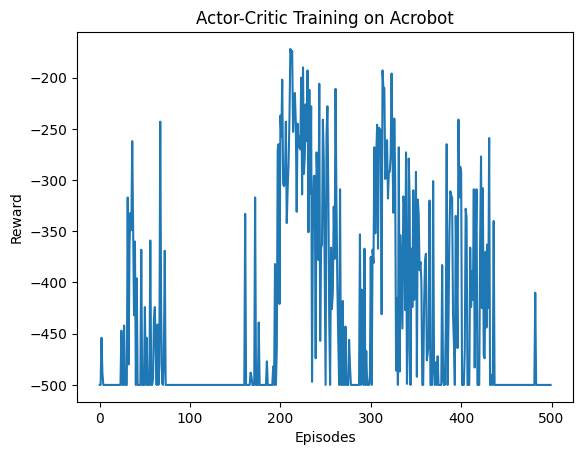

In [ ]:
plt.plot(scores)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Actor-Critic Training on Acrobot")
plt.show()

In [ ]:
env = gym.make("Acrobot-v1", render_mode="human")

state, _ = env.reset()
state = torch.FloatTensor(state)

total_reward = 0

while True:
    with torch.no_grad():
        policy, _ = model(state)

    action = torch.argmax(policy).item()

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    state = torch.FloatTensor(next_state)
    total_reward += reward

    if done:
        break

print("Evaluation Reward:", total_reward)
env.close()

Evaluation Reward: -500.0
